In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

In [2]:
#Đọc dữ liệu:
file = "insurance2024.xlsx"
data = pd.read_excel(file)
data.head(5)

,id,name,age,sex,bmi,children,salary,smoker,region,expenses
0,1,name1,19,female,27.9,0.0,21984.47,yes,southwest,16884.92
1,2,name2,18,male,33.8,1.0,1725.55,no,southeast,1725.55
2,3,name3,28,male,33,3.0,3756.62,no,southeast,4449.46
3,4,name4,33,male,22.7,0.0,3756.62,no,northwest,21984.47
4,5,name5,32,male,28.9,0.0,39611.76,no,northwest,3866.86


# 1. Tìm hiểu tập dữ liệu:

### a. Data types:

In [3]:
data.dtypes

id            int64
name         object
age           int64
sex          object
bmi          object
children    float64
salary      float64
smoker       object
region       object
expenses    float64
dtype: object

### b. Thống kê mô tả:

In [4]:
# Thống kê mô tả khái quát bộ dữ liệu:
data.describe(include = "all")

,id,name,age,sex,bmi,children,salary,smoker,region,expenses
count,1338.000000,742,1338.000000,1337,1338.0,1337.000000,25.000000,1336,1338,1337.000000
unique,NaN,742,NaN,6,278.0,NaN,NaN,5,4,NaN
top,NaN,name1,NaN,male,33.3,NaN,NaN,no,southeast,NaN
freq,NaN,1,NaN,665,17.0,NaN,NaN,1062,364,NaN
mean,669.500000,NaN,39.482810,NaN,NaN,1.167539,15063.330400,NaN,NaN,13268.741219
std,386.391641,NaN,17.325001,NaN,NaN,2.961134,13900.967037,NaN,NaN,12114.386381
min,1.000000,NaN,18.000000,NaN,NaN,0.000000,1137.010000,NaN,NaN,1121.870000
25%,335.250000,NaN,27.000000,NaN,NaN,0.000000,3756.620000,NaN,NaN,4738.270000
50%,669.500000,NaN,39.000000,NaN,NaN,1.000000,10797.340000,NaN,NaN,9377.900000
75%,1003.750000,NaN,51.000000,NaN,NaN,2.000000,21984.470000,NaN,NaN,16657.720000


### c. Tóm tắt thông tin:

In [5]:
data.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 1338 entries, 0 to 1337
Data columns (total 10 columns):
 #   Column    Non-Null Count  Dtype  
---  ------    --------------  -----  
 0   id        1338 non-null   int64  
 1   name      742 non-null    object 
 2   age       1338 non-null   int64  
 3   sex       1337 non-null   object 
 4   bmi       1338 non-null   object 
 5   children  1337 non-null   float64
 6   salary    25 non-null     float64
 7   smoker    1336 non-null   object 
 8   region    1338 non-null   object 
 9   expenses  1337 non-null   float64
dtypes: float64(3), int64(2), object(5)
memory usage: 104.7+ KB


# 2. Sắp xếp và làm sạch dữ liệu (wrangling and cleaning):

### a. Giá trị bị thiếu (missing value):

In [6]:
# Kiểm tra số lượng giá trị bị thiếu:
data.isna().sum()

id             0
name         596
age            0
sex            1
bmi            0
children       1
salary      1313
smoker         2
region         0
expenses       1
dtype: int64

In [7]:
#Đối với cột name, thay thế giá trị trống bằng unknown vì thuộc tính name không ảnh hưởng hoặc ít ảnh hưởng đến kết quả mô hình học máy sau này.
data['name'] = data['name'].fillna('Unknown')

In [8]:
# Đối với cột sex, children,smoker chỉ có một giá trị bị thiếu ta quyết định thay thế nó bằng mode:
data['sex'] = data['sex'].fillna(data["sex"].mode()[0])
data['children'] = data['children'].fillna(data['children'].mode()[0])
data['smoker'] = data['smoker'].fillna(data['smoker'].mode()[0])
# Đối với cột expenses vì dùng làm target feature cho mô hình machine learning nên sẽ bỏ dòng có giá trị trống này
data = data.dropna(subset=['expenses'])

In [9]:
# Cột salary trống quá nhiều gần như là toàn bộ dữ liệu, nếu ta sử dụng phương pháp fillna thì kết quả của mô hình machine learning sau này sẽ không tốt.
# Phương án 1: Có thể cân nhắc sử dụng KNN để điền missing value.
# Phương án 2: Loại bỏ luôn cột này khi huấn luyện mô hình.
# Qua các bước phân tích sau sẽ cân nhắc xử lý tiếp.
data["salary"].unique()

array([21984.47,  1725.55,  3756.62, 39611.76,  1837.24, 10797.34,
        2395.17, 10602.39, 36837.47, 13228.85,  4149.74,  1137.01,
       37701.88,  6203.9 , 14001.13, 14451.84, 12268.63,  2775.19,
       38711.  , 35585.58,      nan])

In [10]:
# Dữ liệu sau khi xử lý missing value:
data.isna().sum()

id             0
name           0
age            0
sex            0
bmi            0
children       0
salary      1312
smoker         0
region         0
expenses       0
dtype: int64

### b. Định dạng dữ liệu (formatting):

In [11]:
data.age.unique()

array([ 19,  18,  28,  33,  32,  31,  46,  37,  60,  25,  62,  23,  56,
        27,  52,  30,  34,  59,  63,  55,  22,  26,  35,  24,  41,  38,
        36,  21,  48,  40,  58,  53,  43,  64,  20,  61,  44,  57,  29,
        45,  54,  49,  47,  51,  42,  50,  39, 410], dtype=int64)

In [12]:
#có 1 giá trị tuổi là 410, không hợp lý có thể do lỗi typing, đổi lại thành 410.
data.loc[:, 'age'] = data['age'].replace(410, 41)

In [13]:
data.age.unique()

array([19, 18, 28, 33, 32, 31, 46, 37, 60, 25, 62, 23, 56, 27, 52, 30, 34,
       59, 63, 55, 22, 26, 35, 24, 41, 38, 36, 21, 48, 40, 58, 53, 43, 64,
       20, 61, 44, 57, 29, 45, 54, 49, 47, 51, 42, 50, 39], dtype=int64)

In [14]:
data.sex.unique()

array(['female', 'male', 'MALE', 'M', 'FEMALE', 'F'], dtype=object)

In [15]:
# Dữ liệu giới tính không nhất quán, quy chung về M cho male và F cho female
data.loc[:, 'sex'] = data['sex'].replace('female','F')
data.loc[:, 'sex'] = data['sex'].replace('male','M')
data.loc[:, 'sex'] = data['sex'].replace('MALE','M')
data.loc[:, 'sex'] = data['sex'].replace('FEMALE','M')

In [16]:
data.sex.unique()

array(['F', 'M'], dtype=object)

In [17]:
data.bmi.unique()

array([27.9, 33.8, 33, 22.7, 28.9, 25.7, 33.4, 27.7, 29.8, 25.8, 26.2,
       26.3, '34.4', 39.8, 42.1, 24.6, 30.8, 23.8, 40.3, 35.3, 36, 32.4,
       34.1, 31.9, 28, 23.1, 32.8, 17.4, 36.3, 35.6, 28.6, 28.3, 36.4,
       20.4, 20.8, 36.7, 39.9, 26.6, 36.6, 21.8, 37.1, 37.3, 38.7, 34.8,
       24.5, 35.2, 33.6, 34.4, 28.7, 37, 31.8, 31.7, 22.9, 27.4, 33.7,
       24.7, 25.9, 22.4, 39.1, 36.2, 24, 24.8, 28.5, 28.1, 32, 34, 29.6,
       35.5, 26.9, 38.3, 37.6, 41.2, 31.2, 27.2, 27, 39.5, 31.3, '37.6',
       20, 19.3, 31.6, 25.5, 30.1, 29.9, 27.5, 28.4, 30.9, 35.1, 29.7,
       35.7, 32.2, 49.1, 23.4, 29, 31.4, 33.9, 28.8, 37.4, 17.8, 34.7,
       26.5, 22, 35.9, 25.6, 25.2, 32.5, 25.3, 38.8, 30.5, 37.7, 24.1,
       24.4, 27.8, 36.9, 39.6, 28.2, 33.2, 18.9, 41.5, 30.3, 16, 33.3,
       29.2, 26.4, 30.7, 41.9, 32.1, 30.6, 18.1, 39.3, 36.1, 22.3, 26.7,
       23.2, 38.1, 22.2, 38.4, 29.1, 22.1, 26.8, 30, 20.9, 17.3, 34.2,
       25.4, 40.2, 24.3, 42.4, 19.8, 30.2, 29.4, 27.6, 20.6, 21.6, 

In [18]:
# Ta thấy bmi bị đưa về object, ta cần tìm ra giá trị bị lỗi typing khiến cột này không conver về float được.
for bmi in data.bmi.unique():
    if not(isinstance(bmi, float)) and not(isinstance(bmi, int)):
        print(bmi)

34.4
37.6
30,,,2


In [19]:
data.loc[:, 'bmi'] = data['bmi'].replace('30,,,2',30.2)
data.loc[:, 'bmi'] = data['bmi'].replace('34.4',34.4)
data['bmi'] = data['bmi'].replace('37.6', 37.6)
data = data.infer_objects(copy=False)

C:\Users\MSI\AppData\Local\Temp\ipykernel_21372\2149260954.py:3: FutureWarning: Downcasting behavior in `replace` is deprecated and will be removed in a future version. To retain the old behavior, explicitly call `result.infer_objects(copy=False)`. To opt-in to the future behavior, set `pd.set_option('future.no_silent_downcasting', True)`
  data['bmi'] = data['bmi'].replace('37.6', 37.6)


In [20]:
# Sau khi xử lý các giá trị lỗi xong
for bmi in data.bmi.unique():
    if not(isinstance(bmi, float)) and not(isinstance(bmi, int)):
        print(bmi)

In [21]:
data.bmi.dtype

dtype('float64')

In [22]:
# Chuyển giá trị 100 thành giá trị 1 và chuyển về type int
data.loc[:, 'children'] = data['children'].replace(100.,1.)
data['children'] = data['children'].astype(int)

In [23]:
data.children.unique()

array([0, 1, 3, 2, 5, 4])

In [24]:
data.children.unique()

array([0, 1, 3, 2, 5, 4])

In [25]:
data.columns

Index(['id', 'name', 'age', 'sex', 'bmi', 'children', 'salary', 'smoker',
       'region', 'expenses'],
      dtype='object')

In [26]:
data.smoker.unique()

array(['yes', 'no', 'Y', 'N', 'Yes'], dtype=object)

In [27]:
# Dữ liệu hút thuốc không nhất quán, quy chung về Y cho yes và N cho no
data.loc[:, 'smoker'] = data['smoker'].replace('yes','Y')
data.loc[:, 'smoker'] = data['smoker'].replace('no','N')
data.loc[:, 'smoker'] = data['smoker'].replace('Yes','Y')

In [28]:
data.smoker.unique()

array(['Y', 'N'], dtype=object)

In [29]:
data.region.unique()

array(['southwest', 'southeast', 'northwest', 'northeast'], dtype=object)

In [30]:
data.expenses.dtype

dtype('float64')

In [31]:
data.salary.dtype

dtype('float64')

# 3. EDA phân tích thăm dò bộ dữ liệu

In [32]:
data.columns

Index(['id', 'name', 'age', 'sex', 'bmi', 'children', 'salary', 'smoker',
       'region', 'expenses'],
      dtype='object')

### a. Central tendencies (hướng trung tâm) - mean, median, mode:

In [33]:
# Giá trị trung bình - mean
mean_values = data[['age', 'bmi', 'expenses']].mean()
print(mean_values)

age            39.222887
bmi            30.669559
expenses    13268.741219
dtype: float64


In [34]:
# Giá trị xuất hiện nhiều nhất - mode
mode_values = data[['age', 'sex', 'children','smoker','region']].mode()
print(mode_values)

   age  sex  children smoker     region
0   18    M       0.0      N  southeast
1   19  NaN       NaN    NaN        NaN


In [35]:
# Giá trị trung vị - median
mode_values = data[['age', 'bmi', 'expenses']].median()
print(mode_values)

age           39.0
bmi           30.4
expenses    9377.9
dtype: float64


### b. Disperson (hướng phân tán) - range, IQR + loại bỏ outlier, correlation độ tương quan giữa các biến với target.

#### Range

In [36]:
col = ['age', 'bmi', 'expenses','children','salary']
for c in col:
    print("max " + c, data[c].max())
    print("min " + c, data[c].min())
    print("range " + c, data[c].max() - data[c].min())
    print("---------")

max age 64
min age 18
range age 46
---------
max bmi 53.1
min bmi 16.0
range bmi 37.1
---------
max expenses 63770.43
min expenses 1121.87
range expenses 62648.56
---------
max children 5
min children 0
range children 5
---------
max salary 39611.76
min salary 1137.01
range salary 38474.75
---------


#### Dùng IQR (box plot) để tìm ra và loại bỏ outlier

In [37]:
data.columns

Index(['id', 'name', 'age', 'sex', 'bmi', 'children', 'salary', 'smoker',
       'region', 'expenses'],
      dtype='object')

In [38]:
# Tìm ra các dòng outlier:
def IQR(col):
    Q1 = data[col].quantile(0.25)  # Phân vị thứ nhất (25%)
    Q3 = data[col].quantile(0.75)  # Phân vị thứ ba (75%)
    IQR = Q3 - Q1
    outliers = data[(data[col] < (Q1 - 1.5 * IQR)) | (data[col] > (Q3 + 1.5 * IQR))]
    return pd.DataFrame(outliers)

def removeOutlier(col,data):
    Q1 = data[col].quantile(0.25)  # Phân vị thứ nhất (25%)
    Q3 = data[col].quantile(0.75)  # Phân vị thứ ba (75%)
    IQR = Q3 - Q1
    lower_bound = Q1 - 1.5 * IQR
    upper_bound = Q3 + 1.5 * IQR
    
    # Loại bỏ các giá trị ngoại lệ
    data = data[(data[col] >= lower_bound) & (data[col] <= upper_bound)]
    return data
    

##### Outlier cho bmi

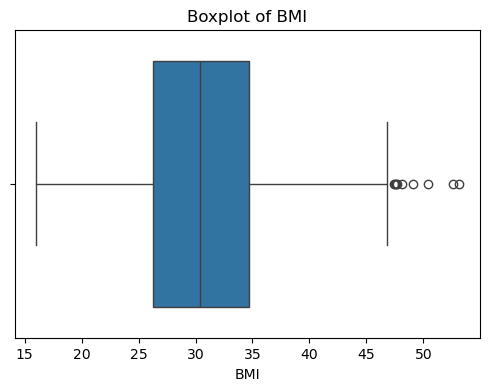

In [39]:
plt.figure(figsize=(6, 4))
sns.boxplot(x=data['bmi'])
plt.title('Boxplot of BMI')
plt.xlabel('BMI')
plt.show()

In [40]:
IQR("bmi")

,id,name,age,sex,bmi,children,salary,smoker,region,expenses
116,117,name117,58,M,49.1,0,NaN,N,southeast,11381.33
286,287,name287,46,F,48.1,2,NaN,N,northeast,9432.93
401,402,name402,47,M,47.5,1,NaN,N,southeast,8083.92
543,544,name544,54,F,47.4,0,NaN,Y,southeast,63770.43
847,848,Unknown,23,M,50.4,1,NaN,N,southeast,2438.06
860,861,Unknown,37,F,47.6,2,NaN,Y,southwest,46113.51
1047,1048,Unknown,22,M,52.6,1,NaN,Y,southeast,44501.40
1088,1089,Unknown,52,M,47.7,1,NaN,N,southeast,9748.91
1317,1318,Unknown,18,M,53.1,0,NaN,N,southeast,1163.46


In [95]:
data = removeOutlier("bmi",data)

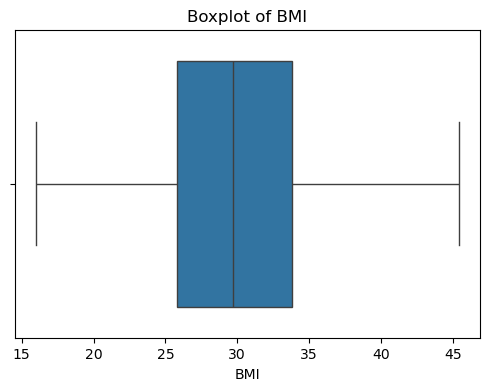

In [96]:
plt.figure(figsize=(6, 4))
sns.boxplot(x=data['bmi'])
plt.title('Boxplot of BMI')
plt.xlabel('BMI')
plt.show()

#### Outlier cho biến target expenses

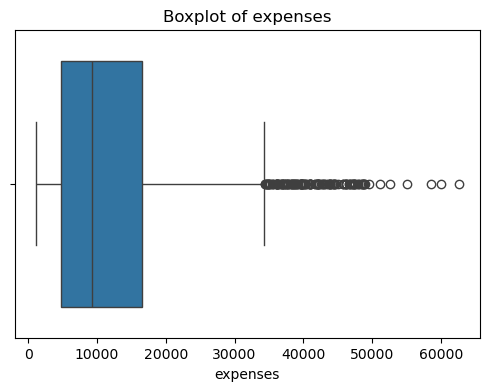

In [43]:
plt.figure(figsize=(6, 4))
sns.boxplot(x=data['expenses'])
plt.title('Boxplot of expenses')
plt.xlabel('expenses')
plt.show()

In [44]:
IQR("expenses")

,id,name,age,sex,bmi,children,salary,smoker,region,expenses
14,15,name15,27,M,42.1,0,13228.85,Y,southeast,39611.76
19,20,name20,30,M,35.3,0,14001.13,Y,southwest,36837.47
23,24,name24,34,F,31.9,1,38711.00,Y,northeast,37701.88
29,30,name30,31,M,36.3,2,NaN,Y,southwest,38711.00
30,31,name31,22,M,35.6,0,NaN,Y,southwest,35585.58
...,...,...,...,...,...,...,...,...,...,...
1300,1301,Unknown,45,M,30.4,0,NaN,Y,southeast,62592.87
1301,1302,Unknown,62,M,30.9,3,NaN,Y,northwest,46718.16
1303,1304,Unknown,43,M,27.8,0,NaN,Y,southwest,37829.72
1313,1314,Unknown,19,F,34.7,2,NaN,Y,southwest,36397.58


In [91]:
data = removeOutlier("expenses",data)

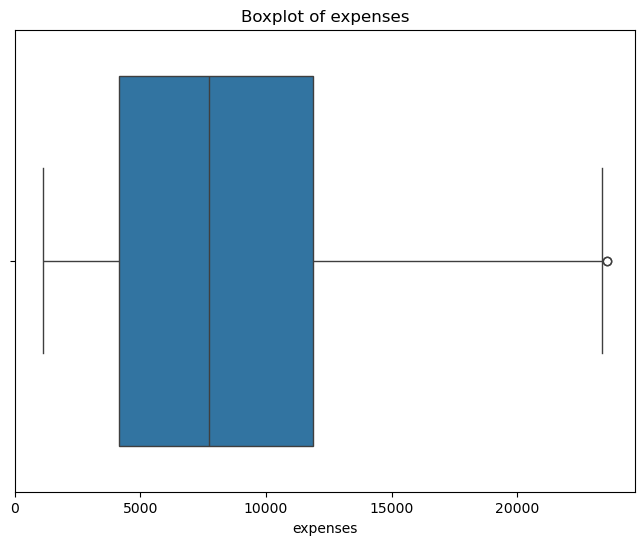

In [92]:
plt.figure(figsize=(8, 6))
sns.boxplot(x=data['expenses'])
plt.title('Boxplot of expenses')
plt.xlabel('expenses')
plt.show()

#### Outlier cho biến age

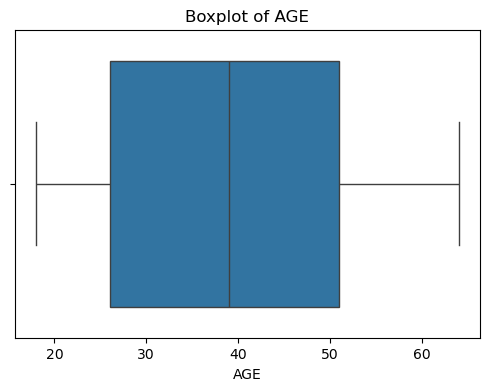

In [47]:
plt.figure(figsize=(6, 4))
sns.boxplot(x=data['age'])
plt.title('Boxplot of AGE')
plt.xlabel('AGE')
plt.show()

### c. Correlation (độ tương quan):

In [48]:
data.describe()

,id,age,bmi,children,salary,expenses
count,1190.000000,1190.000000,1190.000000,1190.000000,22.000000,1190.000000
mean,671.195798,39.028571,29.999076,1.085714,14120.103636,9896.384025
std,384.667901,14.049325,5.870935,1.215701,13894.854266,7188.554584
min,1.000000,18.000000,16.000000,0.000000,1137.010000,1121.870000
25%,345.250000,26.000000,25.800000,0.000000,3020.547500,4405.462500
50%,670.500000,39.000000,29.700000,1.000000,10602.390000,8345.035000
75%,999.750000,51.000000,33.800000,2.000000,20101.312500,12949.842500
max,1338.000000,64.000000,46.800000,5.000000,39611.760000,34303.170000


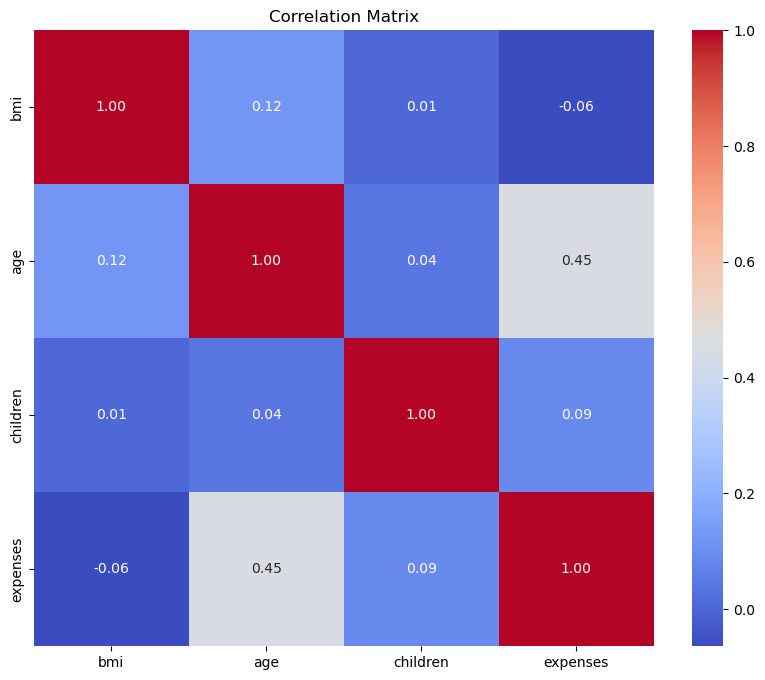

In [49]:
correlation_matrix = data[['bmi','age','children','expenses']].corr()
plt.figure(figsize=(10, 8))
sns.heatmap(correlation_matrix, annot=True, cmap='coolwarm', fmt=".2f")
plt.title('Correlation Matrix')
plt.show()

In [50]:
data["sex"].value_counts()

sex
F    608
M    582
Name: count, dtype: int64

<Axes: xlabel='sex', ylabel='expenses'>

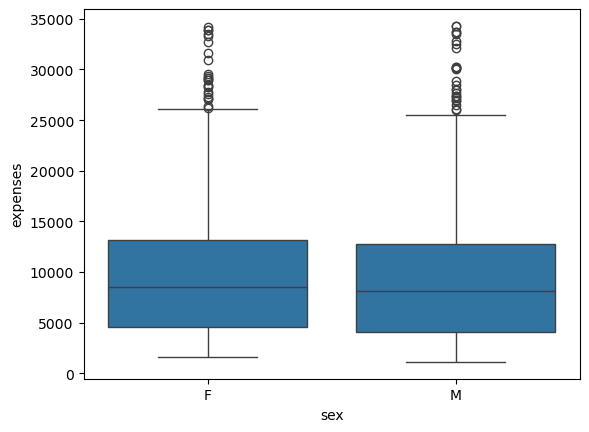

In [51]:
sns.boxplot(x="sex",y="expenses",data = data)

<Axes: xlabel='children', ylabel='expenses'>

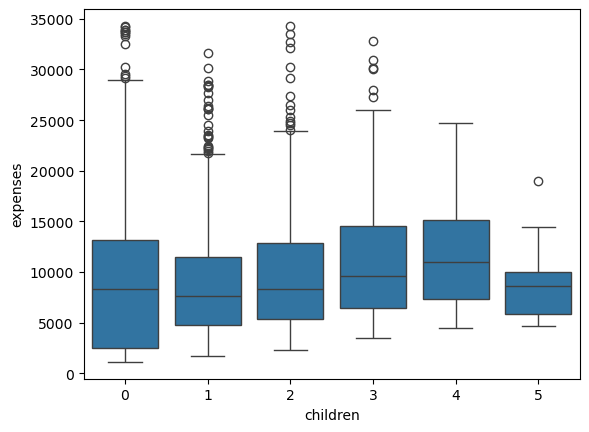

In [52]:
sns.boxplot(x="children",y="expenses",data = data)

<Axes: xlabel='region', ylabel='expenses'>

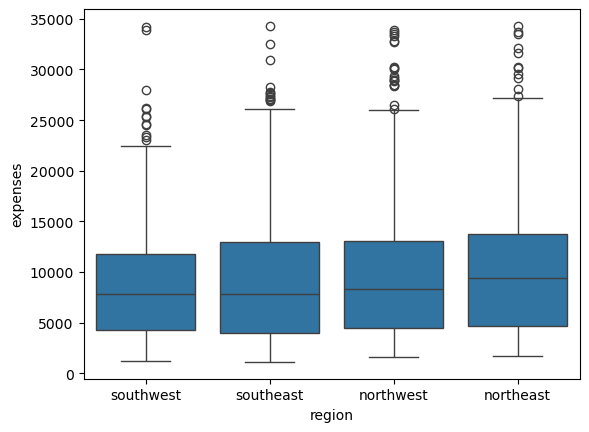

In [53]:
sns.boxplot(x="region",y="expenses",data = data)

<Axes: xlabel='smoker', ylabel='expenses'>

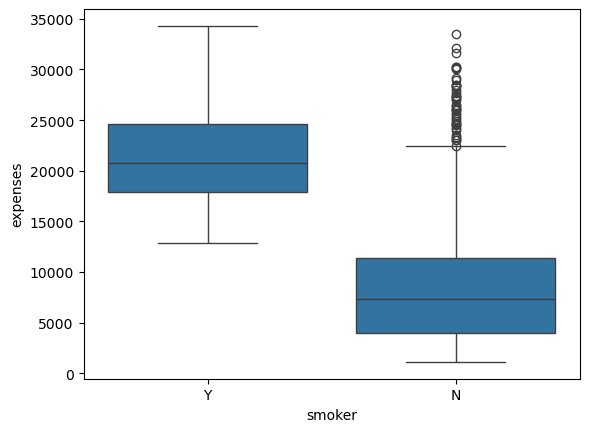

In [54]:
sns.boxplot(x="smoker",y="expenses",data = data)

<Axes: xlabel='age', ylabel='expenses'>

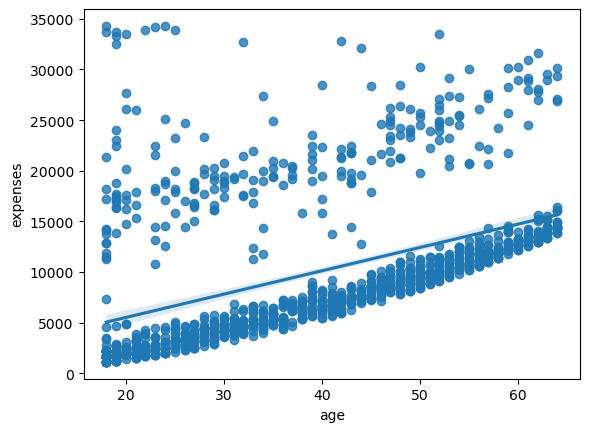

In [55]:
sns.regplot(x = "age",y = "expenses",data = data)

<Axes: xlabel='bmi', ylabel='expenses'>

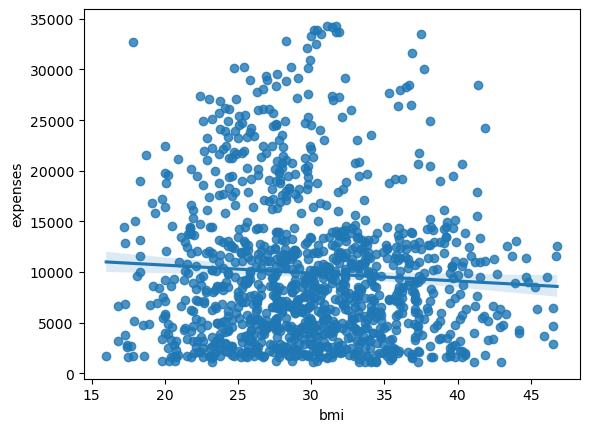

In [56]:
sns.regplot(x = "bmi",y = "expenses",data = data)

In [57]:
data.columns

Index(['id', 'name', 'age', 'sex', 'bmi', 'children', 'salary', 'smoker',
       'region', 'expenses'],
      dtype='object')

# 4. PHÁT TRIỂN MÔ HÌNH (MODEL DEVELOPMENT):

In [97]:
from sklearn.model_selection import train_test_split
from sklearn.linear_model import LinearRegression
from sklearn.metrics import mean_squared_error, r2_score
from sklearn.preprocessing import MinMaxScaler, LabelEncoder
from sklearn.compose import ColumnTransformer
from sklearn.preprocessing import OneHotEncoder

#### Tiền xử lý dữ liệu:

In [98]:
X = data[['age','sex','bmi','children','smoker']].copy()

In [99]:
#Min-max normalization cho cột bmi.
scaler_bmi = MinMaxScaler()
scaler_age = MinMaxScaler()
scaler_children = MinMaxScaler()
X['bmi'] = scaler_bmi.fit_transform(X[['bmi']])
X['age'] = scaler_age.fit_transform(X[['age']])
X['children'] = scaler_children.fit_transform(X[['children']])

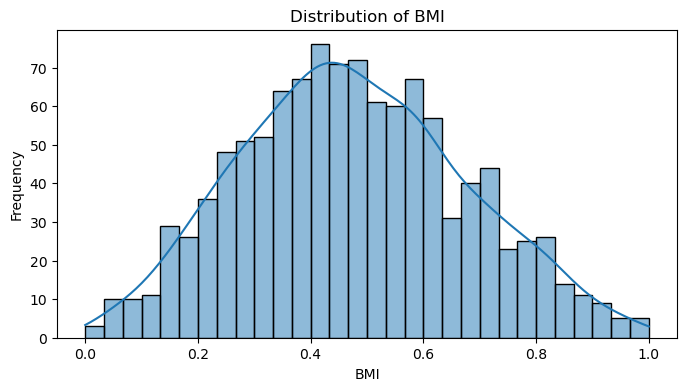

In [100]:
# Vẽ distribution plot cho cột 'bmi'
plt.figure(figsize=(8, 4))
sns.histplot(X['bmi'], kde=True, bins=30)  # kde=True để vẽ đường cong KDE
plt.title('Distribution of BMI')
plt.xlabel('BMI')
plt.ylabel('Frequency')
plt.show()

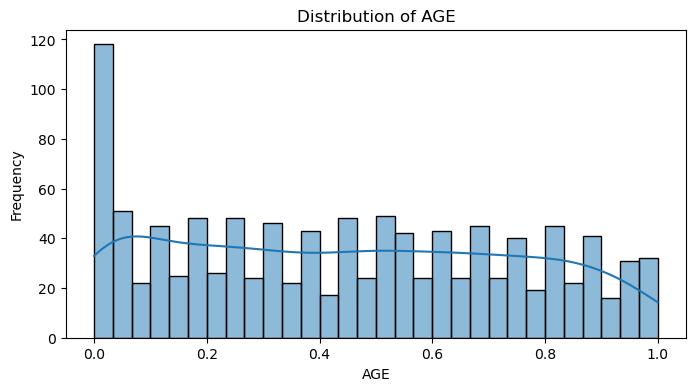

In [101]:
# Vẽ distribution plot cho cột 'bmi'
plt.figure(figsize=(8, 4))
sns.histplot(X['age'], kde=True, bins=30)  # kde=True để vẽ đường cong KDE
plt.title('Distribution of AGE')
plt.xlabel('AGE')
plt.ylabel('Frequency')
plt.show()

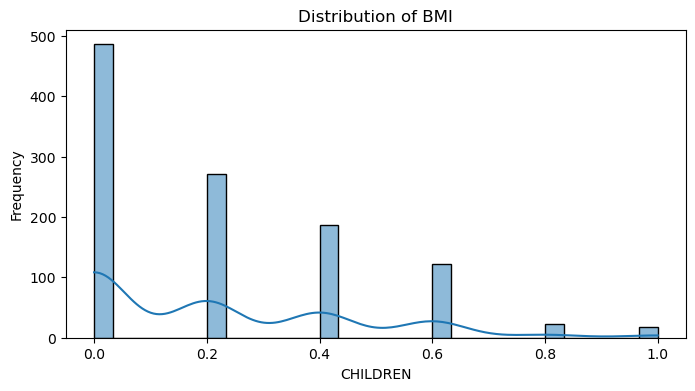

In [102]:
# Vẽ distribution plot cho cột 'bmi'
plt.figure(figsize=(8, 4))
sns.histplot(X['children'], kde=True, bins=30)  # kde=True để vẽ đường cong KDE
plt.title('Distribution of BMI')
plt.xlabel('CHILDREN')
plt.ylabel('Frequency')
plt.show()

In [103]:
#Binary encoding cho cột sex và cột smoker
label_encoder_sex = LabelEncoder()
label_encoder_smoker = LabelEncoder()
X['sex'] = label_encoder_sex.fit_transform(X['sex'])
X['smoker'] = label_encoder_smoker.fit_transform(X['smoker'])

In [104]:
X.head(5)

,age,sex,bmi,children,smoker
0,0.021739,0,0.404762,0.0,1
1,0.000000,1,0.605442,0.2,0
2,0.217391,1,0.578231,0.6,0
3,0.326087,1,0.227891,0.0,0
4,0.304348,1,0.438776,0.0,0


## TRAINING MODEL:

In [105]:
y = data['expenses']

X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

#### Multiple Linear Regression (Hồi quy đa biến):

In [106]:
model = LinearRegression()

In [107]:
model.fit(X_train, y_train)

LinearRegression()

In [108]:
y_pred = model.predict(X_test)

In [109]:
mse = mean_squared_error(y_test, y_pred)
r2 = r2_score(y_test, y_pred)

In [110]:
print("Mean Squared Error (MSE):", mse)
print("R-squared (R²):", r2)

Mean Squared Error (MSE): 7887512.953533254
R-squared (R²): 0.6981966704367408


#### Ridge Regression

In [111]:
from sklearn.linear_model import Ridge

In [112]:
ridge_model = Ridge(alpha=1.0)
ridge_model.fit(X_train, y_train)

Ridge()

In [113]:
y_pred_ridge = ridge_model.predict(X_test)

mse_ridge = mean_squared_error(y_test, y_pred_ridge)
r2_ridge = r2_score(y_test, y_pred_ridge)

In [114]:
print("Ridge MSE:", mse_ridge)
print("Ridge R²:", r2_ridge)

Ridge MSE: 7877163.048580597
Ridge R²: 0.6985926933394957


#### Lasso Regression

In [115]:
from sklearn.linear_model import Lasso

lasso_model = Lasso(alpha=0.1)
lasso_model.fit(X_train, y_train)

y_pred_lasso = lasso_model.predict(X_test)

mse_lasso = mean_squared_error(y_test, y_pred_lasso)
r2_lasso = r2_score(y_test, y_pred_lasso)

print("Lasso MSE:", mse_lasso)
print("Lasso R²:", r2_lasso)

Lasso MSE: 7887052.595320809
Lasso R²: 0.6982142853227165


#### Decision Tree

In [116]:
from sklearn.tree import DecisionTreeRegressor

tree_model = DecisionTreeRegressor(random_state=42)
tree_model.fit(X_train, y_train)

y_pred_tree = tree_model.predict(X_test)

mse_tree = mean_squared_error(y_test, y_pred_tree)
r2_tree = r2_score(y_test, y_pred_tree)

print("Decision Tree MSE:", mse_tree)
print("Decision Tree R²:", r2_tree)

Decision Tree MSE: 19408977.925086427
Decision Tree R²: 0.2573458584829459


#### Random Forest Regressor

In [117]:
from sklearn.ensemble import RandomForestRegressor

rf_model = RandomForestRegressor(n_estimators=100, random_state=42)
rf_model.fit(X_train, y_train)

y_pred_rf = rf_model.predict(X_test)

mse_rf = mean_squared_error(y_test, y_pred_rf)
r2_rf = r2_score(y_test, y_pred_rf)

print("Random Forest MSE:", mse_rf)
print("Random Forest R²:", r2_rf)

Random Forest MSE: 11270828.365511881
Random Forest R²: 0.5687394052235744


#### Gradient boosting

In [118]:
from sklearn.ensemble import GradientBoostingRegressor

gb_model = GradientBoostingRegressor(n_estimators=100, random_state=42)
gb_model.fit(X_train, y_train)

y_pred_gb = gb_model.predict(X_test)

mse_gb = mean_squared_error(y_test, y_pred_gb)
r2_gb = r2_score(y_test, y_pred_gb)

print("Gradient Boosting MSE:", mse_gb)
print("Gradient Boosting R²:", r2_gb)

Gradient Boosting MSE: 8690835.864246687
Gradient Boosting R²: 0.6674587774410585


#### Hồi quy đa thức - Polynomial Regression

In [119]:
from sklearn.preprocessing import PolynomialFeatures


# Degree 1 (Linear Regression)
poly1 = PolynomialFeatures(degree=1)
X_poly1 = poly1.fit_transform(X_train)

model1 = LinearRegression()
model1.fit(X_poly1, y_train)

X_test_poly1 = poly1.transform(X_test)
y_pred_poly1 = model1.predict(X_test_poly1)

mse_poly1 = mean_squared_error(y_test, y_pred_poly1)
r2_poly1 = r2_score(y_test, y_pred_poly1)

print("Polynomial Degree 1 (Linear) MSE:", mse_poly1)
print("Polynomial Degree 1 (Linear) R²:", r2_poly1)

# Degree 2 (Quadratic Regression)
poly2 = PolynomialFeatures(degree=2)
X_poly2 = poly2.fit_transform(X_train)

model2 = LinearRegression()
model2.fit(X_poly2, y_train)

X_test_poly2 = poly2.transform(X_test)
y_pred_poly2 = model2.predict(X_test_poly2)

mse_poly2 = mean_squared_error(y_test, y_pred_poly2)
r2_poly2 = r2_score(y_test, y_pred_poly2)

print("Polynomial Degree 2 (Quadratic) MSE:", mse_poly2)
print("Polynomial Degree 2 (Quadratic) R²:", r2_poly2)

# Degree 3 (Cubic Regression)
poly3 = PolynomialFeatures(degree=3)
X_poly3 = poly3.fit_transform(X_train)

model3 = LinearRegression()
model3.fit(X_poly3, y_train)

X_test_poly3 = poly3.transform(X_test)
y_pred_poly3 = model3.predict(X_test_poly3)

mse_poly3 = mean_squared_error(y_test, y_pred_poly3)
r2_poly3 = r2_score(y_test, y_pred_poly3)

print("Polynomial Degree 3 (Cubic) MSE:", mse_poly3)
print("Polynomial Degree 3 (Cubic) R²:", r2_poly3)

# Degree 4 (Quartic Regression)
poly4 = PolynomialFeatures(degree=4)
X_poly4 = poly4.fit_transform(X_train)

model4 = LinearRegression()
model4.fit(X_poly4, y_train)

X_test_poly4 = poly4.transform(X_test)
y_pred_poly4 = model4.predict(X_test_poly4)

mse_poly4 = mean_squared_error(y_test, y_pred_poly4)
r2_poly4 = r2_score(y_test, y_pred_poly4)

print("Polynomial Degree 4 (Quartic) MSE:", mse_poly4)
print("Polynomial Degree 4 (Quartic) R²:", r2_poly4)

Polynomial Degree 1 (Linear) MSE: 7887512.95353325
Polynomial Degree 1 (Linear) R²: 0.6981966704367408
Polynomial Degree 2 (Quadratic) MSE: 7673045.209829479
Polynomial Degree 2 (Quadratic) R²: 0.7064029427452666
Polynomial Degree 3 (Cubic) MSE: 7808678.233313477
Polynomial Degree 3 (Cubic) R²: 0.7012131575332037
Polynomial Degree 4 (Quartic) MSE: 7912445.3760997895
Polynomial Degree 4 (Quartic) R²: 0.6972426703369643


### KẾT LUẬN CHỌN MÔ HÌNH HỒI QUY ĐA BIẾN BẬC 2 VỚI TẬP TRAINING FEATURE LÀ AGE, SEX, BMI, CHILDREN, SMOKER ĐỂ PREDICT FEATURE EXPANSES
#### R-SQUARED : 0.783

# 5.PREDICTION - THỰC HIỆN DỰ ĐOÁN BẰNG MÔ HÌNH MACHINE LEARNING


In [120]:
def preprocess_data(data):
    scaler = MinMaxScaler()
    data['bmi'] = scaler.fit_transform(data[['bmi']])
    data['age'] = scaler.fit_transform(data[['age']])
    data['children'] = scaler.fit_transform(data[['children']])

    label_encoder = LabelEncoder()
    data['sex'] = label_encoder.fit_transform(data['sex'])
    data['smoker'] = label_encoder.fit_transform(data['smoker'])
    
    return data


In [121]:
def prediction(new_data, model, poly_features):
    # Chuẩn bị dữ liệu đầu vào
    new_data = preprocess_data(new_data)
    X_new_poly = poly_features.transform(new_data)
    
    # Dự đoán
    y_pred = model.predict(X_new_poly)
    return y_pred


In [122]:
data.head(5)

,id,name,age,sex,bmi,children,salary,smoker,region,expenses
0,1,name1,19,F,27.9,0,21984.47,Y,southwest,16884.92
1,2,name2,18,M,33.8,1,1725.55,N,southeast,1725.55
2,3,name3,28,M,33.0,3,3756.62,N,southeast,4449.46
3,4,name4,33,M,22.7,0,3756.62,N,northwest,21984.47
4,5,name5,32,M,28.9,0,39611.76,N,northwest,3866.86


In [123]:

def preprocess_data(data):
    scaler = MinMaxScaler()
    data['bmi'] = scaler.fit_transform(data[['bmi']])
    data['age'] = scaler.fit_transform(data[['age']])
    data['children'] = scaler.fit_transform(data[['children']])

    label_encoder = LabelEncoder()
    data['sex'] = label_encoder.fit_transform(data['sex'])
    data['smoker'] = label_encoder.fit_transform(data['smoker'])
    
    return data


def predict_single(age, sex, bmi, children, smoker, model, poly_features):
    # Chuẩn hóa và mã hóa các giá trị đầu vào
    age_scaled = scaler_age.transform(np.array([[age]]))[0, 0]
    bmi_scaled = scaler_bmi.transform(np.array([[bmi]]))[0, 0]
    children_scaled = scaler_children.transform(np.array([[children]]))[0, 0]
    sex_encoded = label_encoder_sex.transform([sex])[0]
    smoker_encoded = label_encoder_smoker.transform([smoker])[0]

    # Tạo mảng đầu vào sau khi xử lý
    input_data = np.array([[age_scaled, sex_encoded, bmi_scaled, children_scaled, smoker_encoded]])
    input_poly = poly_features.transform(input_data)

    # Dự đoán
    y_pred = model.predict(input_poly)
    return y_pred[0]

# Kiểm tra hàm dự đoán với một bộ thông số
age = 30
sex = 'M'
bmi = 25
children = 4
smoker = 'N'
predicted_expense = predict_single(age, sex, bmi, children, smoker, model2, poly2)

print(f'Dự đoán chi phí y tế: {predicted_expense}')

Dự đoán chi phí y tế: 7031.189051622323


C:\Program Files\Anaconda3\Lib\site-packages\sklearn\base.py:493: UserWarning: X does not have valid feature names, but MinMaxScaler was fitted with feature names
  warnings.warn(
C:\Program Files\Anaconda3\Lib\site-packages\sklearn\base.py:493: UserWarning: X does not have valid feature names, but MinMaxScaler was fitted with feature names
  warnings.warn(
C:\Program Files\Anaconda3\Lib\site-packages\sklearn\base.py:493: UserWarning: X does not have valid feature names, but MinMaxScaler was fitted with feature names
  warnings.warn(
C:\Program Files\Anaconda3\Lib\site-packages\sklearn\base.py:493: UserWarning: X does not have valid feature names, but PolynomialFeatures was fitted with feature names
  warnings.warn(


In [124]:
import joblib
joblib.dump(model2, 'model.pkl')

['model.pkl']

In [125]:
joblib.dump(scaler_age, 'scaler_age.pkl')
joblib.dump(scaler_bmi, 'scaler_bmi.pkl')
joblib.dump(scaler_children, 'scaler_children.pkl')
joblib.dump(label_encoder_sex, 'label_encoder_sex.pkl')
joblib.dump(label_encoder_smoker, 'label_encoder_smoker.pkl')
joblib.dump(poly2, 'poly_features.pkl')

['poly_features.pkl']